# Linear Regression on Fuel (Petrol and Diesel)
### Simple Supervised Learning Project

**Objective:** Study the relationship between fuel price and fuel consumption using Simple Linear Regression.

This project is intentionally kept at a normal syllabus level.

## 1. Import Libraries
We use pandas for data handling, matplotlib for charts, and scikit-learn for the basic regression model.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## 2. Load the Dataset

In [13]:
df = pd.read_csv('../dataset/fuel_data.csv')
df.head()

,Fuel_Type,Fuel_Price_per_Litre,Distance_km,Fuel_Consumption_L_per_100km
0,Petrol,105.35,156.4,8.58
1,Diesel,97.32,167.4,6.76
2,Petrol,106.14,305.2,8.76
3,Diesel,100.66,193.8,7.08
4,Petrol,103.08,228.1,8.44


## 3. Basic Data Understanding

In [14]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(50000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Fuel_Type                     50000 non-null  str    
 1   Fuel_Price_per_Litre          50000 non-null  float64
 2   Distance_km                   50000 non-null  float64
 3   Fuel_Consumption_L_per_100km  50000 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.5 MB
None
       Fuel_Price_per_Litre   Distance_km  Fuel_Consumption_L_per_100km
count          50000.000000  50000.000000                  50000.000000
mean             100.012730    299.874322                      7.676046
std                5.023311    115.655155                      0.915416
min               90.000000    100.000000                      6.000000
25%               96.520000    199.600000                      6.850000
50%              100.020000    300.100000            

## 4. Petrol and Diesel Comparison

Fuel_Type
Diesel     97.02495
Petrol    103.00051
Name: Fuel_Price_per_Litre, dtype: float64


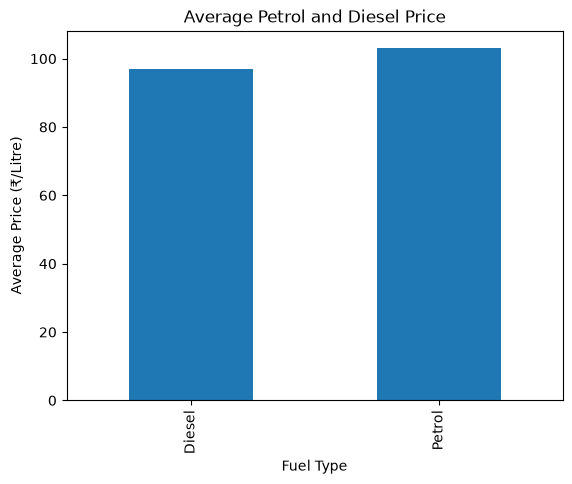

In [15]:
print(df.groupby('Fuel_Type')['Fuel_Price_per_Litre'].mean())

df.groupby('Fuel_Type')['Fuel_Price_per_Litre'].mean().plot(kind='bar')
plt.title('Average Petrol and Diesel Price')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (₹/Litre)')
plt.show()

## 5. Visualize the Relationship

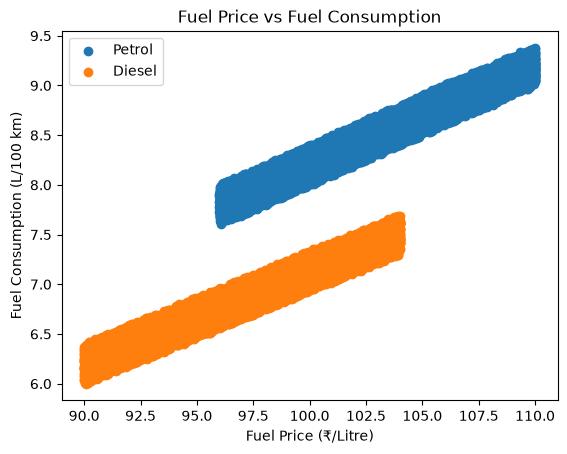

In [16]:
for fuel in ['Petrol', 'Diesel']:
    temp = df[df['Fuel_Type'] == fuel]
    plt.scatter(temp['Fuel_Price_per_Litre'], temp['Fuel_Consumption_L_per_100km'], label=fuel)
plt.xlabel('Fuel Price (₹/Litre)')
plt.ylabel('Fuel Consumption (L/100 km)')
plt.title('Fuel Price vs Fuel Consumption')
plt.legend()
plt.show()

## 6. Prepare Data for Linear Regression
We use **Fuel_Price_per_Litre** as X and **Fuel_Consumption_L_per_100km** as Y.

In [17]:
X = df[['Fuel_Price_per_Litre']]
y = df['Fuel_Consumption_L_per_100km']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 40000
Testing rows: 10000


## 7. Train the Linear Regression Model

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])

Intercept: -8.32657072070216
Coefficient: 0.15999684196493125


## 8. Make Predictions

In [19]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison

,Actual,Predicted
0,6.76,6.820330
1,6.66,6.599535
2,7.26,8.052306
3,6.37,6.223542
4,7.06,7.548316
...,...,...
9995,6.64,7.076325
9996,6.78,7.250722
9997,6.63,6.884329
9998,8.89,8.621895


## 9. Evaluate the Model

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE :', mae)
print('MSE :', mse)
print('RMSE:', rmse)
print('R²  :', r2)

MAE : 0.36629055974118996
MSE : 0.19389872346433487
RMSE: 0.4403393276376014
R²  : 0.7685015206333841


## 10. Regression Line

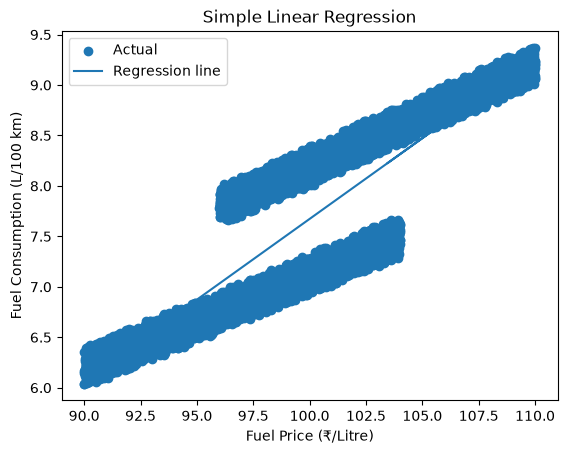

In [21]:
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, label='Regression line')
plt.xlabel('Fuel Price (₹/Litre)')
plt.ylabel('Fuel Consumption (L/100 km)')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

## 11. Actual vs Predicted

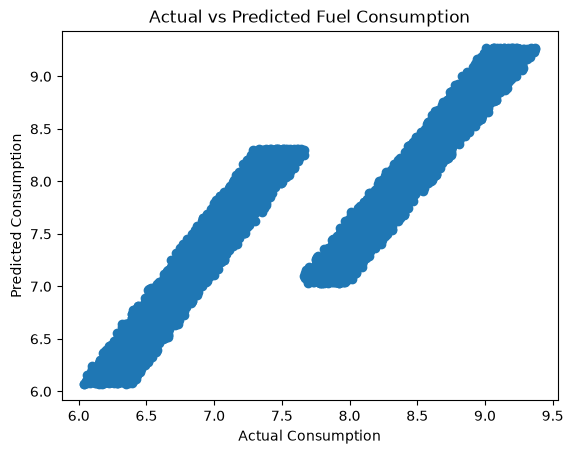

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Consumption')
plt.ylabel('Predicted Consumption')
plt.title('Actual vs Predicted Fuel Consumption')
plt.show()

## 12. Example Prediction
Predict fuel consumption for a fuel price of ₹105 per litre.

In [23]:
new_price = pd.DataFrame({'Fuel_Price_per_Litre': [105]})
prediction = model.predict(new_price)
print('Predicted fuel consumption:', prediction[0], 'L/100 km')

Predicted fuel consumption: 8.473097685615622 L/100 km


## Conclusion
Simple Linear Regression was used to understand the relationship between fuel price and fuel consumption. The model was trained, predictions were made, and basic evaluation metrics were calculated. The charts help visualize the data and regression relationship.